# 09 Network Relationship Graph
Build a categorical relationship graph from the final KPI dataset and export:
- `network_nodes.csv`
- `network_edges.csv`
- `network_summary.csv`

In [1]:
import warnings
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

KPI_CANDIDATES = [
    PROJECT_ROOT / "data" / "processed" / "kpi_dataset.csv",
    PROJECT_ROOT / "backend" / "storage" / "outputs" / "dev_sample" / "kpis.csv",
    PROJECT_ROOT / "notebooks" / "outputs" / "kpi_dataset.csv",
]

kpi_path = next((p for p in KPI_CANDIDATES if p.exists()), None)
if kpi_path is None:
    raise FileNotFoundError(f"No KPI dataset found in candidates: {KPI_CANDIDATES}")

if "backend\storage\outputs" in str(kpi_path):
    OUTPUT_DIR = kpi_path.parent
elif "data\processed" in str(kpi_path):
    OUTPUT_DIR = PROJECT_ROOT / "data" / "processed"
else:
    OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "outputs"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Using KPI dataset: {kpi_path}")
print(f"Output directory: {OUTPUT_DIR}")

Using KPI dataset: C:\Users\hanai\marketing\data\processed\kpi_dataset.csv
Output directory: C:\Users\hanai\marketing\data\processed


In [2]:
REQUIRED_COLUMNS = [
    "business_name",
    "sector",
    "post_type",
    "language",
    "engagement",
    "engagement_rate",
]

RELATIONSHIPS = [
    ("business_name", "sector", "business_name_to_sector", "Business", "Sector"),
    ("business_name", "post_type", "business_name_to_post_type", "Business", "Post Type"),
    ("business_name", "language", "business_name_to_language", "Business", "Language"),
    ("sector", "post_type", "sector_to_post_type", "Sector", "Post Type"),
    ("post_type", "engagement_level", "post_type_to_engagement_level", "Post Type", "Engagement Level"),
    ("language", "engagement_level", "language_to_engagement_level", "Language", "Engagement Level"),
    ("sector", "engagement_level", "sector_to_engagement_level", "Sector", "Engagement Level"),
]

TYPE_PREFIX = {
    "Business": "business",
    "Sector": "sector",
    "Post Type": "post_type",
    "Language": "language",
    "Engagement Level": "engagement_level",
}


def normalize_text_value(value: object) -> str:
    if pd.isna(value):
        return ""
    txt = str(value).strip()
    txt = re.sub(r"\s+", " ", txt)
    return txt.lower()


def make_node_id(node_type: str, label: str) -> str:
    prefix = TYPE_PREFIX[node_type]
    return f"{prefix}:{label}"


def standardize_existing_engagement_level(series: pd.Series) -> pd.Series:
    mapper = {
        "low": "low_engagement",
        "medium": "medium_engagement",
        "high": "high_engagement",
        "low_engagement": "low_engagement",
        "medium_engagement": "medium_engagement",
        "high_engagement": "high_engagement",
    }
    out = series.astype(str).str.strip().str.lower().map(mapper)
    return out


def label_by_quantiles(values: pd.Series, low_q: float, high_q: float) -> pd.Series:
    low_thr = values.quantile(low_q)
    high_thr = values.quantile(high_q)
    out = pd.Series("medium_engagement", index=values.index)
    out.loc[values <= low_thr] = "low_engagement"
    out.loc[values >= high_thr] = "high_engagement"
    return out


def label_by_fixed_rate(values: pd.Series, low_thr: float = 0.03, high_thr: float = 0.08) -> pd.Series:
    out = pd.Series("medium_engagement", index=values.index)
    out.loc[values < low_thr] = "low_engagement"
    out.loc[values >= high_thr] = "high_engagement"
    return out


def build_nodes_and_edges(df: pd.DataFrame, min_weight: int = 1):
    edge_frames = []
    node_parts = []

    for source_col, target_col, rel_name, source_type, target_type in RELATIONSHIPS:
        rel_df = (
            df[[source_col, target_col]]
            .dropna(subset=[source_col, target_col])
            .groupby([source_col, target_col], as_index=False)
            .size()
            .rename(columns={"size": "weight"})
        )

        rel_df = rel_df[rel_df["weight"] >= min_weight].copy()

        if rel_df.empty:
            continue

        rel_df["source"] = rel_df[source_col].map(lambda v: make_node_id(source_type, v))
        rel_df["target"] = rel_df[target_col].map(lambda v: make_node_id(target_type, v))
        rel_df["relationship"] = rel_name

        edge_frames.append(rel_df[["source", "target", "relationship", "weight"]])

        src_nodes = rel_df[[source_col]].drop_duplicates().rename(columns={source_col: "label"})
        src_nodes["type"] = source_type
        src_nodes["id"] = src_nodes["label"].map(lambda v: make_node_id(source_type, v))

        tgt_nodes = rel_df[[target_col]].drop_duplicates().rename(columns={target_col: "label"})
        tgt_nodes["type"] = target_type
        tgt_nodes["id"] = tgt_nodes["label"].map(lambda v: make_node_id(target_type, v))

        node_parts.extend([src_nodes[["id", "label", "type"]], tgt_nodes[["id", "label", "type"]]])

    edges = pd.concat(edge_frames, ignore_index=True) if edge_frames else pd.DataFrame(columns=["source", "target", "relationship", "weight"])
    nodes = pd.concat(node_parts, ignore_index=True).drop_duplicates().sort_values(["type", "label"]).reset_index(drop=True) if node_parts else pd.DataFrame(columns=["id", "label", "type"])
    return nodes, edges


def evaluate_method(df: pd.DataFrame, method_name: str):
    nodes, edges = build_nodes_and_edges(df, min_weight=1)

    counts = (
        df["engagement_level"]
        .value_counts(dropna=False)
        .reindex(["low_engagement", "medium_engagement", "high_engagement"], fill_value=0)
    )
    props = counts / max(len(df), 1)
    l1_dist = np.abs(props - (1 / 3)).sum()
    balance_score = 1 - (l1_dist / (4 / 3))

    relationship_coverage = edges["relationship"].nunique() / len(RELATIONSHIPS) if len(RELATIONSHIPS) else 0.0

    n_nodes = len(nodes)
    n_edges = len(edges)
    node_size_score = np.exp(-abs(n_nodes - 120) / 120) if n_nodes > 0 else 0.0
    edge_size_score = np.exp(-abs(n_edges - 200) / 200) if n_edges > 0 else 0.0
    graph_size_score = 0.5 * node_size_score + 0.5 * edge_size_score

    final_score = 0.5 * balance_score + 0.3 * relationship_coverage + 0.2 * graph_size_score

    return {
        "method": method_name,
        "rows": len(df),
        "low_count": int(counts["low_engagement"]),
        "medium_count": int(counts["medium_engagement"]),
        "high_count": int(counts["high_engagement"]),
        "balance_score": float(balance_score),
        "relationship_coverage": float(relationship_coverage),
        "graph_size_score": float(graph_size_score),
        "score": float(final_score),
        "nodes": int(n_nodes),
        "edges": int(n_edges),
    }

## Load and Preprocess

In [3]:
df_raw = pd.read_csv(kpi_path)
print(f"Input dataset shape: {df_raw.shape}")

# Harmonize alternate KPI schemas if needed
if "engagement" not in df_raw.columns and "total_engagement" in df_raw.columns:
    df_raw["engagement"] = df_raw["total_engagement"]
if "engagement_rate" not in df_raw.columns and "engagement_rate_followers" in df_raw.columns:
    df_raw["engagement_rate"] = df_raw["engagement_rate_followers"]

missing_required = [c for c in REQUIRED_COLUMNS if c not in df_raw.columns]
if missing_required:
    raise ValueError(f"Missing required columns after schema harmonization: {missing_required}")

print("Missing values in required columns (before cleaning):")
display(df_raw[REQUIRED_COLUMNS].isna().sum().to_frame("missing_count").T)

df = df_raw.copy()

# Remove rows with missing business_name
before_rows = len(df)
df["business_name"] = df["business_name"].map(normalize_text_value)
df = df[df["business_name"] != ""].copy()
print(f"Rows removed due to missing business_name: {before_rows - len(df)}")

# Fill network categorical columns
for col in ["sector", "post_type", "language"]:
    df[col] = df[col].fillna("Unknown").map(normalize_text_value)
    df.loc[df[col] == "", col] = "unknown"

# Normalize business text after filtering
df["business_name"] = df["business_name"].map(normalize_text_value)

# Numeric safety for engagement columns
df["engagement"] = pd.to_numeric(df["engagement"], errors="coerce")
df["engagement_rate"] = pd.to_numeric(df["engagement_rate"], errors="coerce")

if df["engagement"].isna().all() and {"likes_count", "comments_count"}.issubset(df.columns):
    df["engagement"] = pd.to_numeric(df["likes_count"], errors="coerce").fillna(0) + pd.to_numeric(df["comments_count"], errors="coerce").fillna(0)

if df["engagement_rate"].isna().all() and "followers_count" in df.columns:
    followers = pd.to_numeric(df["followers_count"], errors="coerce").replace(0, np.nan)
    df["engagement_rate"] = (df["engagement"] / followers).replace([np.inf, -np.inf], np.nan)

# Final fill
df["engagement"] = df["engagement"].replace([np.inf, -np.inf], np.nan).fillna(0)
df["engagement_rate"] = df["engagement_rate"].replace([np.inf, -np.inf], np.nan)
if df["engagement_rate"].isna().all():
    df["engagement_rate"] = 0
else:
    df["engagement_rate"] = df["engagement_rate"].fillna(df["engagement_rate"].median())

print(f"Cleaned dataset shape: {df.shape}")
print("Missing values in required columns (after cleaning):")
display(df[REQUIRED_COLUMNS].isna().sum().to_frame("missing_count").T)

Input dataset shape: (656, 43)
Missing values in required columns (before cleaning):


,business_name,sector,post_type,language,engagement,engagement_rate
missing_count,0,0,0,1,0,0


Rows removed due to missing business_name: 0
Cleaned dataset shape: (656, 43)
Missing values in required columns (after cleaning):


,business_name,sector,post_type,language,engagement,engagement_rate
missing_count,0,0,0,0,0,0


## Experiment With Engagement Level Thresholds

In [4]:
methods = {}

# Method 1: existing engagement_level (if valid)
if "engagement_level" in df.columns:
    existing = standardize_existing_engagement_level(df["engagement_level"])
    if existing.notna().mean() >= 0.9:
        m1 = df.copy()
        m1["engagement_level"] = existing.fillna("medium_engagement")
        methods["existing_engagement_level"] = m1

# Method 2: quantile-based 33/33/33 using engagement_rate
m2 = df.copy()
m2["engagement_level"] = label_by_quantiles(m2["engagement_rate"], low_q=1/3, high_q=2/3)
methods["quantile_33_33_33"] = m2

# Method 3: fixed thresholds on engagement_rate
m3 = df.copy()
m3["engagement_level"] = label_by_fixed_rate(m3["engagement_rate"], low_thr=0.03, high_thr=0.08)
methods["fixed_rate_0.03_0.08"] = m3

# Method 4: top 25% high, bottom 25% low
m4 = df.copy()
m4["engagement_level"] = label_by_quantiles(m4["engagement_rate"], low_q=0.25, high_q=0.75)
methods["bottom25_mid50_top25"] = m4

experiment_rows = []
for method_name, method_df in methods.items():
    experiment_rows.append(evaluate_method(method_df, method_name))

experiments_df = pd.DataFrame(experiment_rows).sort_values("score", ascending=False).reset_index(drop=True)

print("Threshold experiment results:")
display(experiments_df)

chosen_method = experiments_df.iloc[0]["method"]
final_df = methods[chosen_method].copy()

print(f"Chosen threshold method: {chosen_method}")
print("Engagement level distribution (chosen method):")
eng_dist = (
    final_df["engagement_level"]
    .value_counts()
    .reindex(["low_engagement", "medium_engagement", "high_engagement"], fill_value=0)
)
display(eng_dist.to_frame("count"))

Threshold experiment results:


,method,rows,low_count,medium_count,high_count,balance_score,relationship_coverage,graph_size_score,score,nodes,edges
0,existing_engagement_level,656,219,218,219,0.998476,1.0,0.679822,0.935202,85,298
1,quantile_33_33_33,656,219,218,219,0.998476,1.0,0.679822,0.935202,85,298
2,bottom25_mid50_top25,656,164,328,164,0.750000,1.0,0.682900,0.811580,85,296
3,fixed_rate_0.03_0.08,656,613,20,23,0.098323,1.0,0.695527,0.488267,85,288


Chosen threshold method: existing_engagement_level
Engagement level distribution (chosen method):


,count
engagement_level,
low_engagement,219
medium_engagement,218
high_engagement,219


## Experiment With Min Edge Weight

In [5]:
min_weight_candidates = [1, 2, 3, 5]

base_nodes, base_edges = build_nodes_and_edges(final_df, min_weight=1)
base_node_count = max(len(base_nodes), 1)

weight_rows = []
filtered_variants = {}
for w in min_weight_candidates:
    ndf, edf = build_nodes_and_edges(final_df, min_weight=w)
    filtered_variants[w] = (ndf, edf)

    node_retention = len(ndf) / base_node_count
    edge_target = 120
    score = -abs(len(edf) - edge_target) / edge_target + 0.4 * node_retention
    if len(edf) < 20:
        score -= 0.3
    if len(edf) > 500:
        score -= 0.3

    weight_rows.append({
        "min_weight": w,
        "nodes": len(ndf),
        "edges": len(edf),
        "node_retention": node_retention,
        "score": score,
    })

min_weight_df = pd.DataFrame(weight_rows).sort_values("score", ascending=False).reset_index(drop=True)
print("Min-weight experiment results:")
display(min_weight_df)

chosen_min_weight = int(min_weight_df.iloc[0]["min_weight"])
network_nodes, network_edges = filtered_variants[chosen_min_weight]

print(f"Chosen min_weight: {chosen_min_weight}")
print(f"Number of nodes: {len(network_nodes)}")
print(f"Number of edges: {len(network_edges)}")

Min-weight experiment results:


,min_weight,nodes,edges,node_retention,score
0,5,65,190,0.764706,-0.277451
1,3,68,218,0.800000,-0.496667
2,2,73,240,0.858824,-0.656471
3,1,85,298,1.000000,-1.083333


Chosen min_weight: 5
Number of nodes: 65
Number of edges: 190


## Save Final CSV Outputs

In [6]:
network_nodes_path = OUTPUT_DIR / "network_nodes.csv"
network_edges_path = OUTPUT_DIR / "network_edges.csv"
network_summary_path = OUTPUT_DIR / "network_summary.csv"

network_nodes.to_csv(network_nodes_path, index=False)
network_edges.to_csv(network_edges_path, index=False)

summary_rows = [
    {"metric": "input_rows", "value": len(df_raw)},
    {"metric": "cleaned_rows", "value": len(final_df)},
    {"metric": "chosen_threshold_method", "value": chosen_method},
    {"metric": "chosen_min_weight", "value": chosen_min_weight},
    {"metric": "nodes_count", "value": len(network_nodes)},
    {"metric": "edges_count", "value": len(network_edges)},
]

for level, count in (
    final_df["engagement_level"]
    .value_counts()
    .reindex(["low_engagement", "medium_engagement", "high_engagement"], fill_value=0)
    .items()
):
    summary_rows.append({"metric": f"engagement_level_{level}", "value": int(count)})

network_summary = pd.DataFrame(summary_rows)
network_summary.to_csv(network_summary_path, index=False)

print(f"Saved: {network_nodes_path}")
print(f"Saved: {network_edges_path}")
print(f"Saved: {network_summary_path}")

# Optional mirror to backend output folder for frontend/backend immediate use
backend_default_out = PROJECT_ROOT / "backend" / "storage" / "outputs" / "dev_sample"
if backend_default_out.exists() and backend_default_out.resolve() != OUTPUT_DIR.resolve():
    backend_default_out.mkdir(parents=True, exist_ok=True)
    network_nodes.to_csv(backend_default_out / "network_nodes.csv", index=False)
    network_edges.to_csv(backend_default_out / "network_edges.csv", index=False)
    network_summary.to_csv(backend_default_out / "network_summary.csv", index=False)
    print(f"Mirrored outputs to: {backend_default_out}")

Saved: C:\Users\hanai\marketing\data\processed\network_nodes.csv
Saved: C:\Users\hanai\marketing\data\processed\network_edges.csv
Saved: C:\Users\hanai\marketing\data\processed\network_summary.csv


## Notebook Display Outputs

Sample network_nodes:


,id,label,type
0,business:528 fashion,528 fashion,Business
1,business:99streetwear,99streetwear,Business
2,business:aburob,aburob,Business
3,business:angel shop ps,angel shop ps,Business
4,business:baby bump,baby bump,Business
5,business:bella kids,bella kids,Business
6,business:bravo supermarket,bravo supermarket,Business
7,business:euromoda,euromoda,Business
8,business:family market ps,family market ps,Business
9,business:farouj abu alabd,farouj abu alabd,Business


Sample network_edges:


,source,target,relationship,weight
0,business:528 fashion,sector:fashion,business_name_to_sector,7
1,business:99streetwear,sector:fashion,business_name_to_sector,9
2,business:aburob,sector:influencers,business_name_to_sector,31
3,business:angel shop ps,sector:fashion,business_name_to_sector,12
4,business:baby bump,sector:fashion,business_name_to_sector,10
5,business:bella kids,sector:fashion,business_name_to_sector,12
6,business:bravo supermarket,sector:supermarkets,business_name_to_sector,8
7,business:euromoda,sector:fashion,business_name_to_sector,8
8,business:family market ps,sector:supermarkets,business_name_to_sector,16
9,business:farouj abu alabd,sector:cafes/restaurants,business_name_to_sector,24


Top 10 strongest edges by weight:


,source,target,relationship,weight
153,sector:fashion,post_type:reel,sector_to_post_type,256
161,post_type:reel,engagement_level:high_engagement,post_type_to_engagement_level,195
163,post_type:reel,engagement_level:medium_engagement,post_type_to_engagement_level,185
162,post_type:reel,engagement_level:low_engagement,post_type_to_engagement_level,167
164,language:arabic,engagement_level:high_engagement,language_to_engagement_level,154
165,language:arabic,engagement_level:low_engagement,language_to_engagement_level,144
166,language:arabic,engagement_level:medium_engagement,language_to_engagement_level,131
152,sector:cafes/restaurants,post_type:reel,sector_to_post_type,121
180,sector:fashion,engagement_level:low_engagement,sector_to_engagement_level,119
181,sector:fashion,engagement_level:medium_engagement,sector_to_engagement_level,101


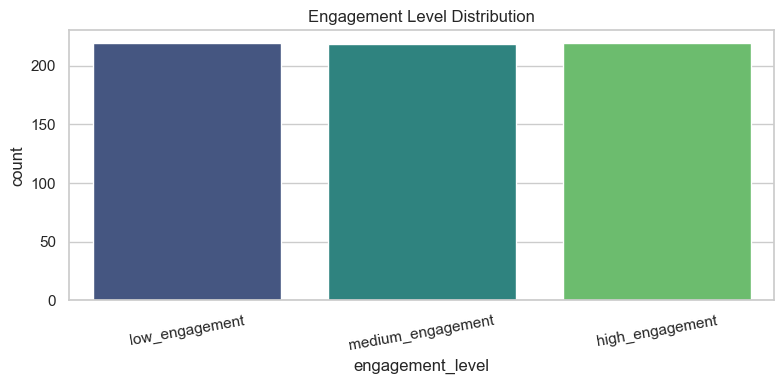

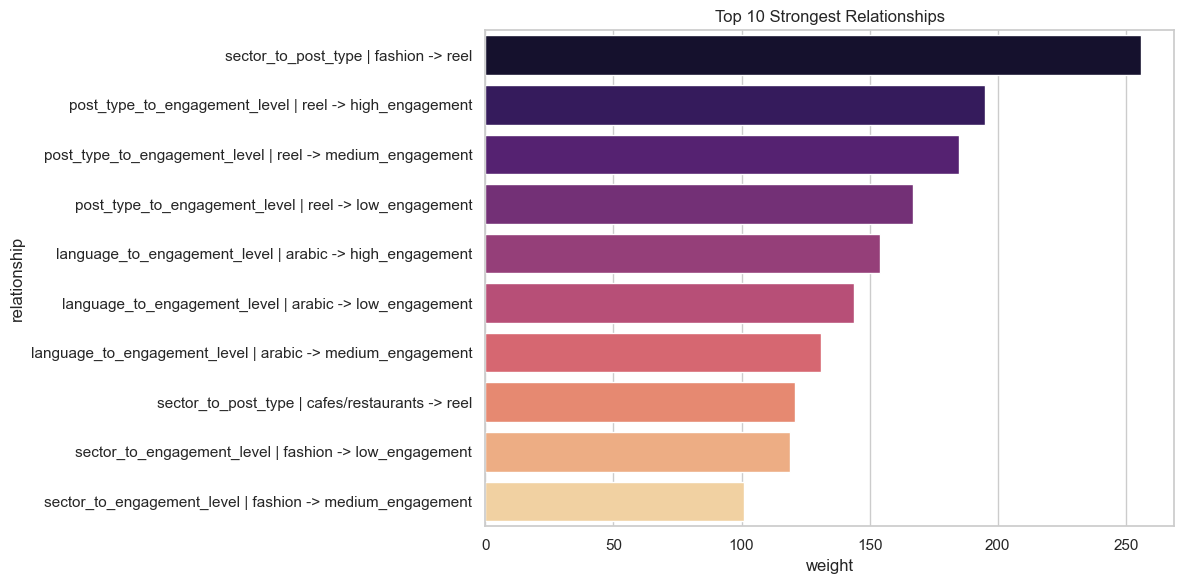

In [ ]:
print("Sample network_nodes:")
display(network_nodes.head(10))

print("Sample network_edges:")
display(network_edges.head(10))

print("Top 10 strongest edges by weight:")
top_edges = network_edges.sort_values("weight", ascending=False).head(10).copy()
display(top_edges)

# Bar chart: engagement level distribution
engagement_dist = (
    final_df["engagement_level"]
    .value_counts()
    .reindex(["low_engagement", "medium_engagement", "high_engagement"], fill_value=0)
)

plt.figure(figsize=(8, 4))
sns.barplot(x=engagement_dist.index, y=engagement_dist.values, palette="viridis")
plt.title("Engagement Level Distribution")
plt.xlabel("engagement_level")
plt.ylabel("count")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

# Bar chart: top 10 strongest relationships
plot_edges = top_edges.copy()
plot_edges["edge_label"] = plot_edges["relationship"] + " | " + plot_edges["source"].str.split(":", n=1).str[1] + " -> " + plot_edges["target"].str.split(":", n=1).str[1]
# Relationship Weight Inference:
# The weight represents how often a relationship appears in the dataset
# A higher weight means a stronger observed connection between two entities,
# such as a post type, language, sector, or engagement level.
# This helps us infer which content features are most strongly associated with high engagement
plt.figure(figsize=(12, 6))
sns.barplot(data=plot_edges, y="edge_label", x="weight", palette="magma")
plt.title("Top 10 Strongest Relationships")
plt.xlabel("weight")
plt.ylabel("relationship")
plt.tight_layout()
plt.show()

## Optional Network Graph Visualization

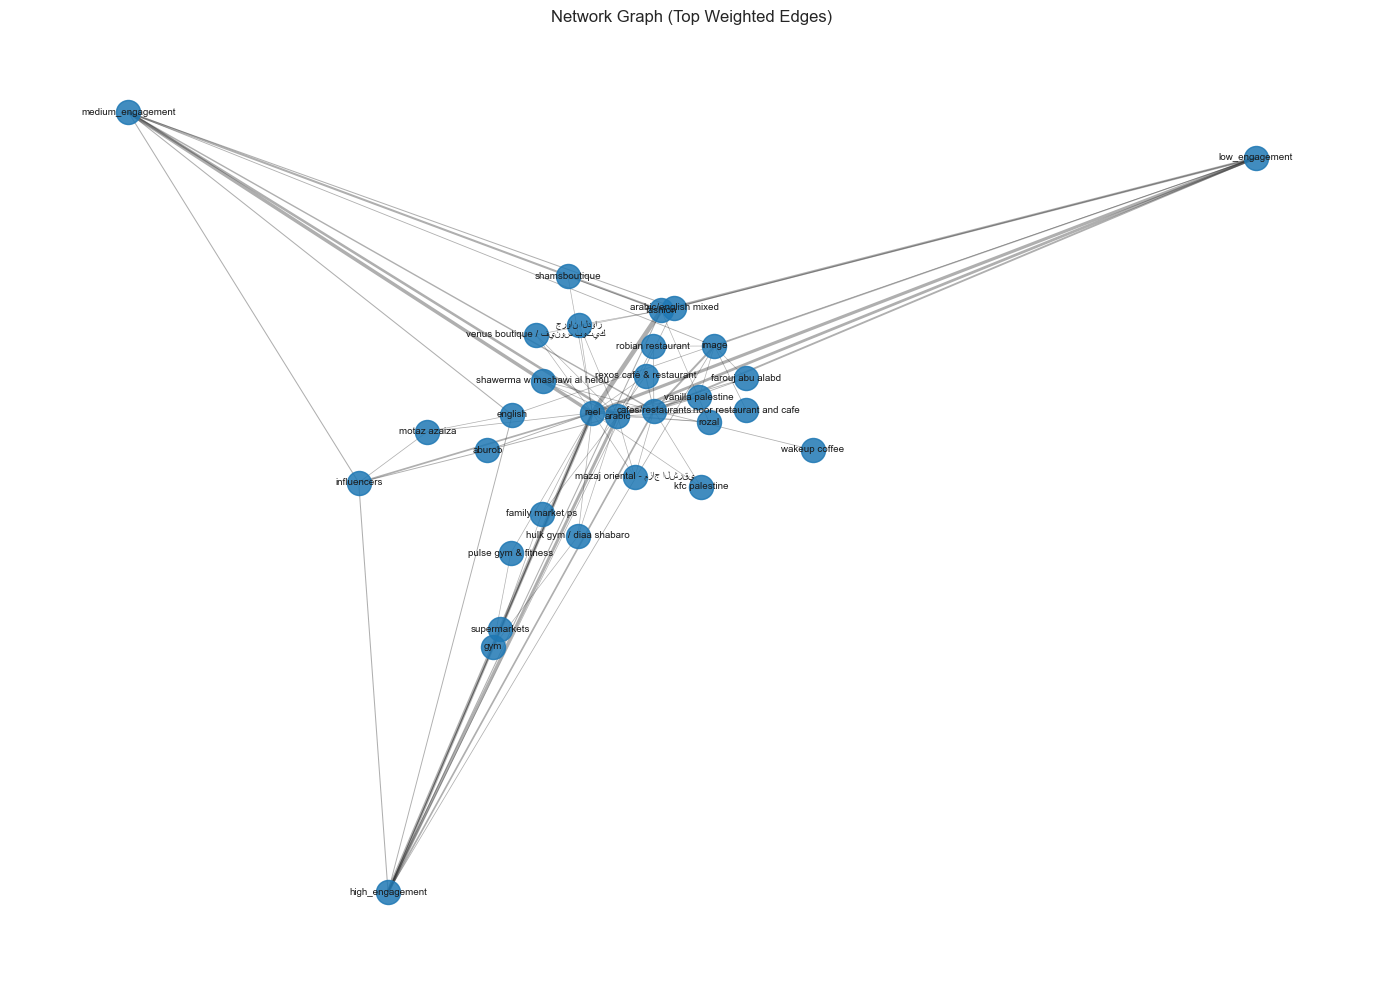

In [ ]:
try:
    import networkx as nx

    g = nx.DiGraph()

    top_for_graph = network_edges.sort_values("weight", ascending=False).head(80)
    for _, row in top_for_graph.iterrows():
        g.add_edge(row["source"], row["target"], weight=float(row["weight"]))

    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(g, seed=42, k=0.7)
    weights = [g[u][v]["weight"] for u, v in g.edges()]

    nx.draw_networkx_nodes(g, pos, node_size=300, alpha=0.85)
    nx.draw_networkx_edges(g, pos, width=[0.3 + (w / max(weights)) * 3 for w in weights], alpha=0.35, arrows=False)
    # Interpretation:
    # Stronger weighted edges indicate more frequent and meaningful relationships in the data.
    # These relationships can support recommendations, such as which post types or languages
    # are more often connected to high engagement.
    labels = {n: n.split(":", 1)[1] for n in g.nodes}
    nx.draw_networkx_labels(g, pos, labels=labels, font_size=7)

    plt.title("Network Graph (Top Weighted Edges)")
    plt.axis("off")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Skipping optional network graph visualization: {e}")

## Final Logging Summary

In [9]:
print("Input dataset shape:", df_raw.shape)
print("Missing values in required columns (final working set):")
print(final_df[REQUIRED_COLUMNS].isna().sum().to_dict())
print("Chosen threshold method:", chosen_method)
print("Chosen min_weight:", chosen_min_weight)
print("Engagement level distribution:")
print(final_df["engagement_level"].value_counts().to_dict())
print("Number of nodes:", len(network_nodes))
print("Number of edges:", len(network_edges))
print("Top 10 strongest edges by weight:")
print(network_edges.sort_values("weight", ascending=False).head(10).to_string(index=False))

Input dataset shape: (656, 43)
Missing values in required columns (final working set):
{'business_name': 0, 'sector': 0, 'post_type': 0, 'language': 0, 'engagement': 0, 'engagement_rate': 0}
Chosen threshold method: existing_engagement_level
Chosen min_weight: 5
Engagement level distribution:
{'high_engagement': 219, 'low_engagement': 219, 'medium_engagement': 218}
Number of nodes: 65
Number of edges: 190
Top 10 strongest edges by weight:
                  source                             target                  relationship  weight
          sector:fashion                     post_type:reel           sector_to_post_type     256
          post_type:reel   engagement_level:high_engagement post_type_to_engagement_level     195
          post_type:reel engagement_level:medium_engagement post_type_to_engagement_level     185
          post_type:reel    engagement_level:low_engagement post_type_to_engagement_level     167
         language:arabic   engagement_level:high_engagement  langua